In [4]:
# PROYECTO ML: PREDICCIÓN DE GASTO

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. GENERAR DATASET

np.random.seed(42)
n = 200

df = pd.DataFrame({
    "edad": np.random.randint(18, 65, n),
    "visitas": np.random.randint(5, 100, n),
    "compras": np.random.randint(1, 20, n),
    "ingresos": np.random.randint(300000, 2000000, n)
})

# Variable objetivo
df["gasto"] = df["visitas"] * 200 + df["compras"] * 500 + np.random.randint(0, 1000, n)

# 2. PREPARACIÓN

X = df.drop("gasto", axis=1)
y = df["gasto"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. MODELOS

models = {
    "Linear": LinearRegression(),
    "KNN": KNeighborsRegressor(),
    "Ridge": Ridge(),
    "Boosting": GradientBoostingRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds)
    }

# 4. RESULTADOS

results_df = pd.DataFrame(results).T
print(results_df)

# 5. OPTIMIZACIÓN (GRID SEARCH)

params = {"alpha": [0.1, 1, 10]}
grid = GridSearchCV(Ridge(), params, cv=5)
grid.fit(X_train, y_train)

print("Mejor modelo:", grid.best_params_)

# 6. VALIDACIÓN CRUZADA

scores = cross_val_score(LinearRegression(), X_train, y_train, cv=5)
print("CV Score:", scores.mean())

                  MAE         RMSE        R2
Linear     256.815656   289.075430  0.997902
KNN       1272.235000  1638.298223  0.932598
Ridge      257.225908   294.834895  0.997817
Boosting   472.505515   591.129201  0.991225
Mejor modelo: {'alpha': 0.1}
CV Score: 0.9974368104394159


Visualizaciones

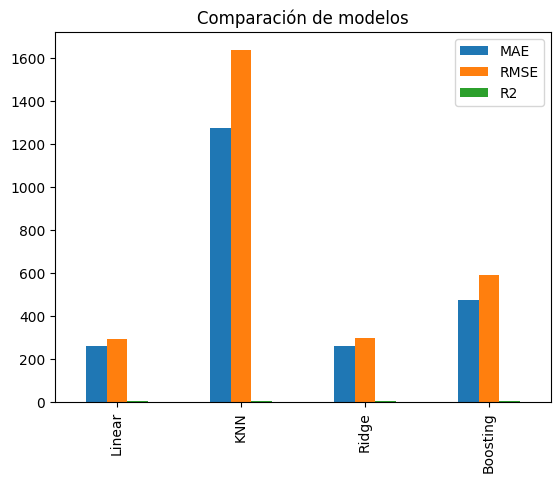

In [5]:
import matplotlib.pyplot as plt

results_df.plot(kind="bar")
plt.title("Comparación de modelos")
plt.show()